# 08 - Ablation Study

Compares baseline, only load-aware scaling, only prediction, and the full proposed model.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
STEPS = 500
RUNS = 120
modes = ['baseline', 'load_aware', 'prediction_only', 'improved']
frames = []
for mode in modes:
    df = SimulationEngine(SimulationConfig()).run(steps=STEPS, runs=RUNS, mode=mode, seed=404)
    frames.append(df)
ablation = pd.concat(frames, ignore_index=True)
ablation.to_csv(DATASET_DIR / 'ablation_dataset.csv', index=False)
summary = pd.DataFrame([{**performance_summary(df), 'mode': mode} for mode, df in zip(modes, frames)])
summary.to_csv(DATASET_DIR / 'ablation_summary.csv', index=False)
summary

,mean_reliability,failure_rate,mean_production,production_variance,mean_accuracy,mean_load,mean_throughput,mode
0,0.547433,0.452567,0.870239,0.050024,0.434506,6.674914,0.367382,baseline
1,0.643983,0.356017,0.931438,0.050984,0.489821,6.118410,0.445307,load_aware
2,0.641117,0.358883,0.927616,0.048249,0.504105,5.979192,0.457447,prediction_only
3,0.655250,0.344750,0.934355,0.046674,0.504058,5.979212,0.461377,improved


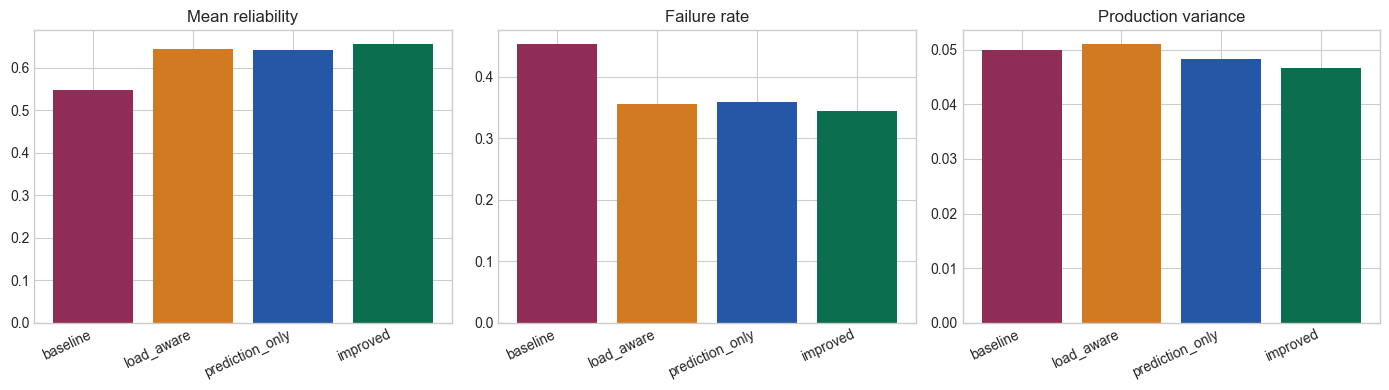

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#8f2d56', '#d17a22', '#2457a6', '#0b6e4f']
x = np.arange(len(summary))
labels = summary['mode'].tolist()
axes[0].bar(x, summary['mean_reliability'], color=colors)
axes[0].set_title('Mean reliability')
axes[1].bar(x, summary['failure_rate'], color=colors)
axes[1].set_title('Failure rate')
axes[2].bar(x, summary['production_variance'], color=colors)
axes[2].set_title('Production variance')
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha='right')
fig.tight_layout()
fig.savefig(GRAPH_DIR / '08_ablation_bars.png', dpi=160)
plt.show()

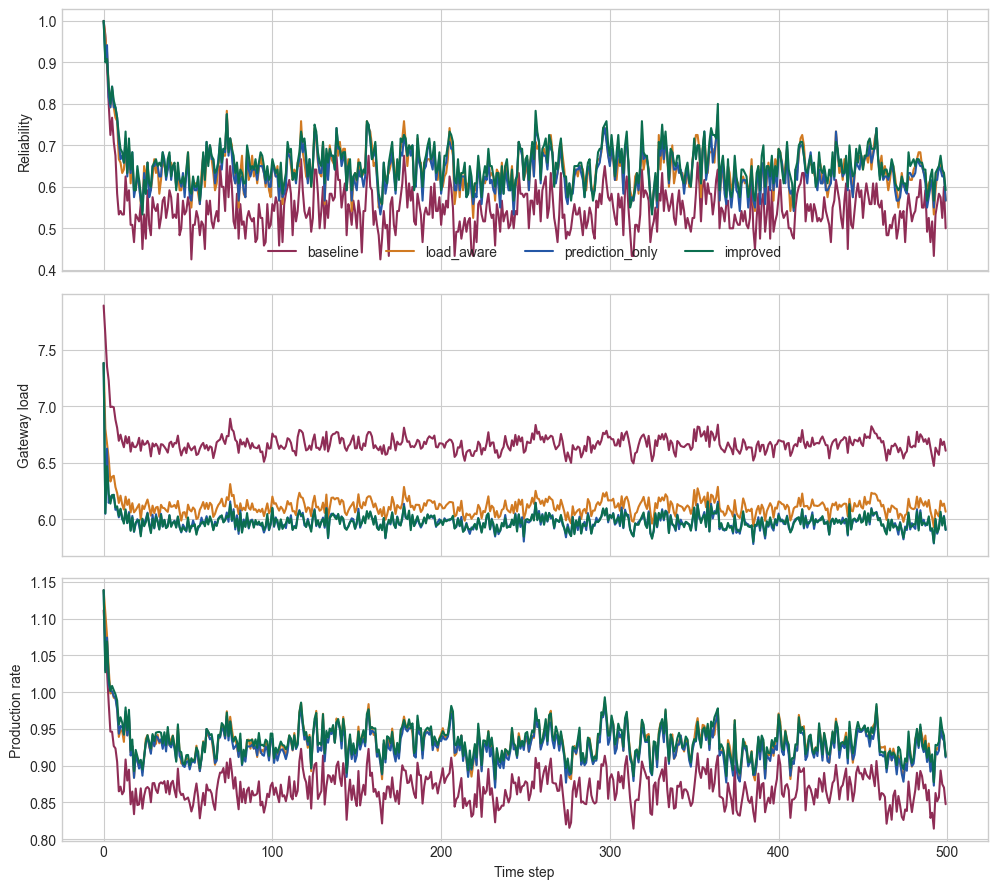

In [4]:
time = ablation.groupby(['mode', 'time'], as_index=False).agg({
    'reliability': 'mean',
    'gateway_load': 'mean',
    'production_rate': 'mean',
})
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for mode, color in zip(modes, colors):
    part = time[time['mode'] == mode]
    axes[0].plot(part['time'], part['reliability'], label=mode, color=color)
    axes[1].plot(part['time'], part['gateway_load'], label=mode, color=color)
    axes[2].plot(part['time'], part['production_rate'], label=mode, color=color)
axes[0].set_ylabel('Reliability')
axes[1].set_ylabel('Gateway load')
axes[2].set_ylabel('Production rate')
axes[2].set_xlabel('Time step')
axes[0].legend(ncol=4, loc='lower center')
fig.tight_layout()
fig.savefig(GRAPH_DIR / '08_ablation_timeseries.png', dpi=160)
plt.show()